In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")

print("Path to dataset files:", path)

c:\Users\khali\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 270M/270M [00:27<00:00, 10.4MB/s] 

Extracting files...


Path to dataset files: C:\Users\khali\.cache\kagglehub\datasets\hrishitpatil\flight-data-2024\versions\2


In [14]:
df = pd.read_csv(path + "/flight_data_2024.csv")
df

C:\Users\khali\AppData\Local\Temp\ipykernel_18316\2322740850.py:1: DtypeWarning: Columns (0: cancellation_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/flight_data_2024.csv")


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7079076,2024,12,31,2,2024-12-31,YX,5857.0,MYR,"Myrtle Beach, SC",South Carolina,...,0,117.0,102.0,76.0,563.0,0,0,0,0,0
7079077,2024,12,31,2,2024-12-31,YX,5859.0,JFK,"New York, NY",New York,...,0,89.0,72.0,51.0,273.0,0,0,0,0,0
7079078,2024,12,31,2,2024-12-31,YX,5859.0,PWM,"Portland, ME",Maine,...,0,89.0,83.0,50.0,273.0,0,0,0,0,0
7079079,2024,12,31,2,2024-12-31,YX,5862.0,JFK,"New York, NY",New York,...,0,89.0,81.0,42.0,209.0,0,0,0,0,0


In [15]:
df.shape

(7079081, 35)

In [ ]:
df.isna().mean()

year                   0.000000e+00
month                  0.000000e+00
day_of_month           0.000000e+00
day_of_week            0.000000e+00
fl_date                0.000000e+00
op_unique_carrier      0.000000e+00
op_carrier_fl_num      1.412613e-07
origin                 0.000000e+00
origin_city_name       0.000000e+00
origin_state_nm        0.000000e+00
dest                   0.000000e+00
dest_city_name         0.000000e+00
dest_state_nm          0.000000e+00
crs_dep_time           0.000000e+00
dep_time               1.308913e-02
dep_delay              1.313306e-02
taxi_out               1.352351e-02
wheels_off             1.352351e-02
wheels_on              1.382326e-02
taxi_in                1.382326e-02
crs_arr_time           0.000000e+00
arr_time               1.382298e-02
arr_delay              1.607751e-02
cancelled              0.000000e+00
cancellation_code      9.863944e-01
diverted               0.000000e+00
crs_elapsed_time       1.412613e-07
actual_elapsed_time    1.607

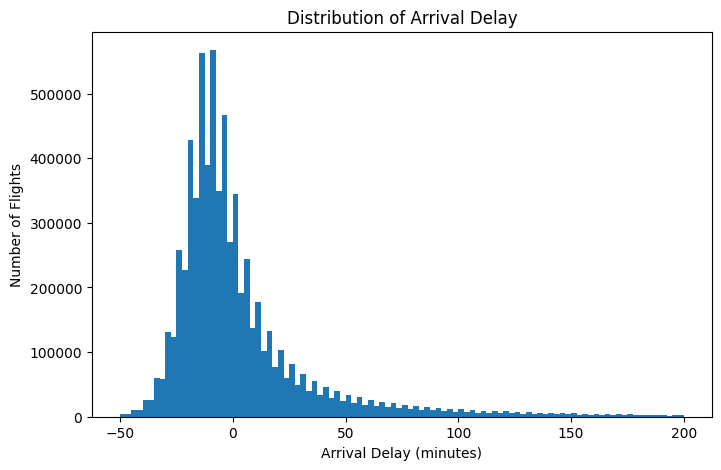

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(df["arr_delay"].dropna(), bins=100, range=(-50, 200))
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Arrival Delay")
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["dep_delay"].dropna(), bins=100, range=(-50, 200))
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Number of Flights")
plt.title("Distribution of Departure Delay")
plt.show()

In [ ]:
carrier_counts = df["op_unique_carrier"].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(carrier_counts.index, carrier_counts.values)
plt.xlabel("Carrier")
plt.ylabel("Number of Flights")
plt.title("Flight Count by Carrier")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_sample = df.sample(500000, random_state=42)

carriers = df_sample["op_unique_carrier"].unique()
delay_by_carrier = []
for carrier in carriers:
    delay_by_carrier.append(df_sample[df_sample["op_unique_carrier"] == carrier]["arr_delay"].dropna())

plt.figure(figsize=(12, 6))
plt.boxplot(delay_by_carrier, labels=carriers, showfliers=False)
plt.xlabel("Carrier")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Delay by Carrier")
plt.xticks(rotation=45)
plt.show()

In [ ]:
avg_delay_by_day = df.groupby("day_of_week")["arr_delay"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_delay_by_day.index, avg_delay_by_day.values)
plt.xlabel("Day of Week (1=Monday)")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Average Arrival Delay by Day of Week")
plt.show()

In [ ]:
avg_delay_by_month = df.groupby("month")["arr_delay"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_delay_by_month.index, avg_delay_by_month.values)
plt.xlabel("Month")
plt.ylabel("Average Arrival Delay (minutes)")
plt.title("Average Arrival Delay by Month")
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(df_sample["distance"], df_sample["arr_delay"], alpha=0.05, s=5)
plt.xlabel("Distance (miles)")
plt.ylabel("Arrival Delay (minutes)")
plt.title("Arrival Delay vs Distance")
plt.show()

In [ ]:
numeric_cols = ["dep_delay", "taxi_out", "taxi_in", "arr_delay", "distance", "crs_elapsed_time", "actual_elapsed_time", "air_time"]
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
missing_pct = df.isna().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 6))
plt.barh(missing_pct.index, missing_pct.values)
plt.xlabel("Missing Percentage")
plt.title("Missing Values by Column")
plt.show()

In [ ]:
cancelled_counts = df["cancelled"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(["Not Cancelled", "Cancelled"], cancelled_counts.values)
plt.ylabel("Number of Flights")
plt.title("Cancelled vs Not Cancelled Flights")
plt.show()